# Downloading the Osborne Mine, Australia,  airborne magnetic survey 

Accessed from https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/142419

Inspired by: https://github.com/fatiando-data/osborne-magnetic/blob/main/prepare.ipynb

In [1]:
import numpy as np
import pandas as pd
import pooch
import pygmt
import pyproj
import verde as vd
import xarray as xr

import airbornegeo

/home/mdtanker/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load data

In [2]:
fname = pooch.retrieve(
    url="https://thredds.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/QLD/line/P1029/P1029-line-magnetic-AWAGS_MAG_2010.nc",
    known_hash="sha256:119b472da05365f0df4e9dc0b2d4b0e5c213705acb4f79efcaa07e1aeeb7242c",
    progressbar=True,
    path=f"{pooch.os_cache('airbornegeo')}",
)
data_ds = xr.open_dataset(fname)
data_ds

<xarray.Dataset> Size: 7GB
Dimensions:            (point: 96100603, line: 11231)
Coordinates:
  * line               (line) float64 90kB 1.0 2.0 3.0 ... 1.123e+04 1.123e+04
Dimensions without coordinates: point
Data variables: (12/14)
    line_index         (point) float64 769MB ...
    areaFlag           (line) float32 45kB ...
    levelFlag          (line) float64 90kB ...
    lineType           (line) float64 90kB ...
    FID                (point) float64 769MB ...
    altitude           (point) float64 769MB ...
    ...                 ...
    mag_awagsLevelled  (point) float32 384MB ...
    mag_microLevelled  (point) float32 384MB ...
    mag_tieLevelled    (point) float64 769MB ...
    latitude           (point) float64 769MB ...
    longitude          (point) float64 769MB ...
    crs                int8 1B ...
Attributes: (12/23)
    CreationTime:             Sun Dec 15 23:09:37 2019
    CreationMethod:           intrepid2netcdf.exe
    IntrepidSourceDataset:    ./mag_database_reformat_adjusted/intrepid/GSQP1...
    median_sample_spacing_m:  6.7
    geospatial_bounds:        POLYGON ((138.000707 -18.061092, 138.000733 -18...
    geospatial_lon_max:       141.34279740678033
    ...                       ...
    institution:              Commonwealth of Australia (Geoscience Australia)
    uuid:                     12ee23de-033c-44f2-8b63-932203d25f39
    Conventions:              CF-1.6, ACDD-1.3
    metadata_link:            http://pid.geoscience.gov.au/dataset/ga/142419
    keywords:                 AWAGS, Australia, Earth sciences, GADDS2.0, QLD...
    licence:                  CC BY 4.0 (C) Commonwealth of Australia (Geosci...

In [30]:
data_df = pd.DataFrame(
    {
        "longitude_gda": data_ds.longitude.data,
        "latitude_gda": data_ds.latitude.data,
        "terrain_clearance_m": data_ds.altitude.data.astype(np.float32),
        "total_field_anomaly_awags_levelled": data_ds.mag_awagsLevelled.data.astype(
            np.float32
        ),
        "total_field_anomaly_microlevelled": data_ds.mag_microLevelled.data.astype(
            np.float32
        ),
        "total_field_anomaly_levelled": data_ds.mag_tieLevelled.data.astype(np.float32),
        "flight_line": data_ds.line_index.data.astype(np.uint16),
    }
)
data_df

,longitude_gda,latitude_gda,terrain_clearance_m,total_field_anomaly_awags_levelled,total_field_anomaly_microlevelled,total_field_anomaly_levelled,flight_line
0,138.501222,-18.997443,92.650002,-68.396271,4880.699219,-42.220001,0
1,138.501287,-18.997448,92.349998,-68.289764,4880.805176,-42.110001,0
2,138.501353,-18.997449,92.040001,-68.173523,4880.920898,-41.990002,0
3,138.501419,-18.997450,91.769997,-68.067039,4881.026855,-41.880001,0
4,138.501485,-18.997451,91.470001,-67.970810,4881.122559,-41.779999,0
...,...,...,...,...,...,...,...
96100598,139.005337,-20.616210,79.879997,-1.867777,4934.700195,-16.299999,11230
96100599,139.005334,-20.616269,79.940002,-1.757627,4934.810059,-16.190001,11230
96100600,139.005331,-20.616332,79.910004,-1.657218,4934.910156,-16.090000,11230
96100601,139.005328,-20.616391,79.820000,-1.567088,4935.000000,-16.000000,11230


## Reproject

In [31]:
data_df["longitude"], data_df["latitude"] = airbornegeo.reproject(
    data_df.longitude_gda,
    data_df.latitude_gda,
    input_crs="epsg:4283",
    output_crs="epsg:4326",
)
region = vd.get_region((data_df.longitude, data_df.latitude))
data_df

,longitude_gda,latitude_gda,terrain_clearance_m,total_field_anomaly_awags_levelled,total_field_anomaly_microlevelled,total_field_anomaly_levelled,flight_line,longitude,latitude
0,138.501222,-18.997443,92.650002,-68.396271,4880.699219,-42.220001,0,138.501222,-18.997443
1,138.501287,-18.997448,92.349998,-68.289764,4880.805176,-42.110001,0,138.501287,-18.997448
2,138.501353,-18.997449,92.040001,-68.173523,4880.920898,-41.990002,0,138.501353,-18.997449
3,138.501419,-18.997450,91.769997,-68.067039,4881.026855,-41.880001,0,138.501419,-18.997450
4,138.501485,-18.997451,91.470001,-67.970810,4881.122559,-41.779999,0,138.501485,-18.997451
...,...,...,...,...,...,...,...,...,...
96100598,139.005337,-20.616210,79.879997,-1.867777,4934.700195,-16.299999,11230,139.005337,-20.616210
96100599,139.005334,-20.616269,79.940002,-1.757627,4934.810059,-16.190001,11230,139.005334,-20.616269
96100600,139.005331,-20.616332,79.910004,-1.657218,4934.910156,-16.090000,11230,139.005331,-20.616332
96100601,139.005328,-20.616391,79.820000,-1.567088,4935.000000,-16.000000,11230,139.005328,-20.616391


## Correct heights

In [32]:
srtm = vd.grid_to_table(
    pygmt.grdcut("@earth_relief_01s_g", region=vd.pad_region(region, 2 / 60))
)
srtm

grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdblend [NOTICE]: Earth Relief at 1x1 arc seconds tiles provided by SRTMGL1 (land only) [NASA/USGS].
grdblend [NOTICE]:   -> Download 1x1 degree grid tile (earth_relief_01s_g): S24E137


,lat,lon,z
0,-23.045833,137.966667,260.0
1,-23.045833,137.966944,259.0
2,-23.045833,137.967222,257.0
3,-23.045833,137.967500,256.0
4,-23.045833,137.967778,254.0
...,...,...,...
247145171,-17.458333,141.378056,21.0
247145172,-17.458333,141.378333,21.0
247145173,-17.458333,141.378611,21.0
247145174,-17.458333,141.378889,21.0


In [33]:
projection = pyproj.Proj(proj="merc", lat_ts=data_df.latitude.mean())

nearest = vd.KNeighbors()
nearest.fit(projection(srtm.lon.values, srtm.lat.values), srtm.z)
topography = nearest.predict(
    projection(data_df.longitude.values, data_df.latitude.values)
)

data_df = data_df.assign(
    height_orthometric_m=topography + data_df.terrain_clearance_m,
)
data_df

,longitude_gda,latitude_gda,terrain_clearance_m,total_field_anomaly_awags_levelled,total_field_anomaly_microlevelled,total_field_anomaly_levelled,flight_line,longitude,latitude,height_orthometric_m
0,138.501222,-18.997443,92.650002,-68.396271,4880.699219,-42.220001,0,138.501222,-18.997443,277.649994
1,138.501287,-18.997448,92.349998,-68.289764,4880.805176,-42.110001,0,138.501287,-18.997448,276.350006
2,138.501353,-18.997449,92.040001,-68.173523,4880.920898,-41.990002,0,138.501353,-18.997449,276.040009
3,138.501419,-18.997450,91.769997,-68.067039,4881.026855,-41.880001,0,138.501419,-18.997450,275.769989
4,138.501485,-18.997451,91.470001,-67.970810,4881.122559,-41.779999,0,138.501485,-18.997451,275.470001
...,...,...,...,...,...,...,...,...,...,...
96100598,139.005337,-20.616210,79.879997,-1.867777,4934.700195,-16.299999,11230,139.005337,-20.616210,412.880005
96100599,139.005334,-20.616269,79.940002,-1.757627,4934.810059,-16.190001,11230,139.005334,-20.616269,412.940002
96100600,139.005331,-20.616332,79.910004,-1.657218,4934.910156,-16.090000,11230,139.005331,-20.616332,412.910004
96100601,139.005328,-20.616391,79.820000,-1.567088,4935.000000,-16.000000,11230,139.005328,-20.616391,412.820007


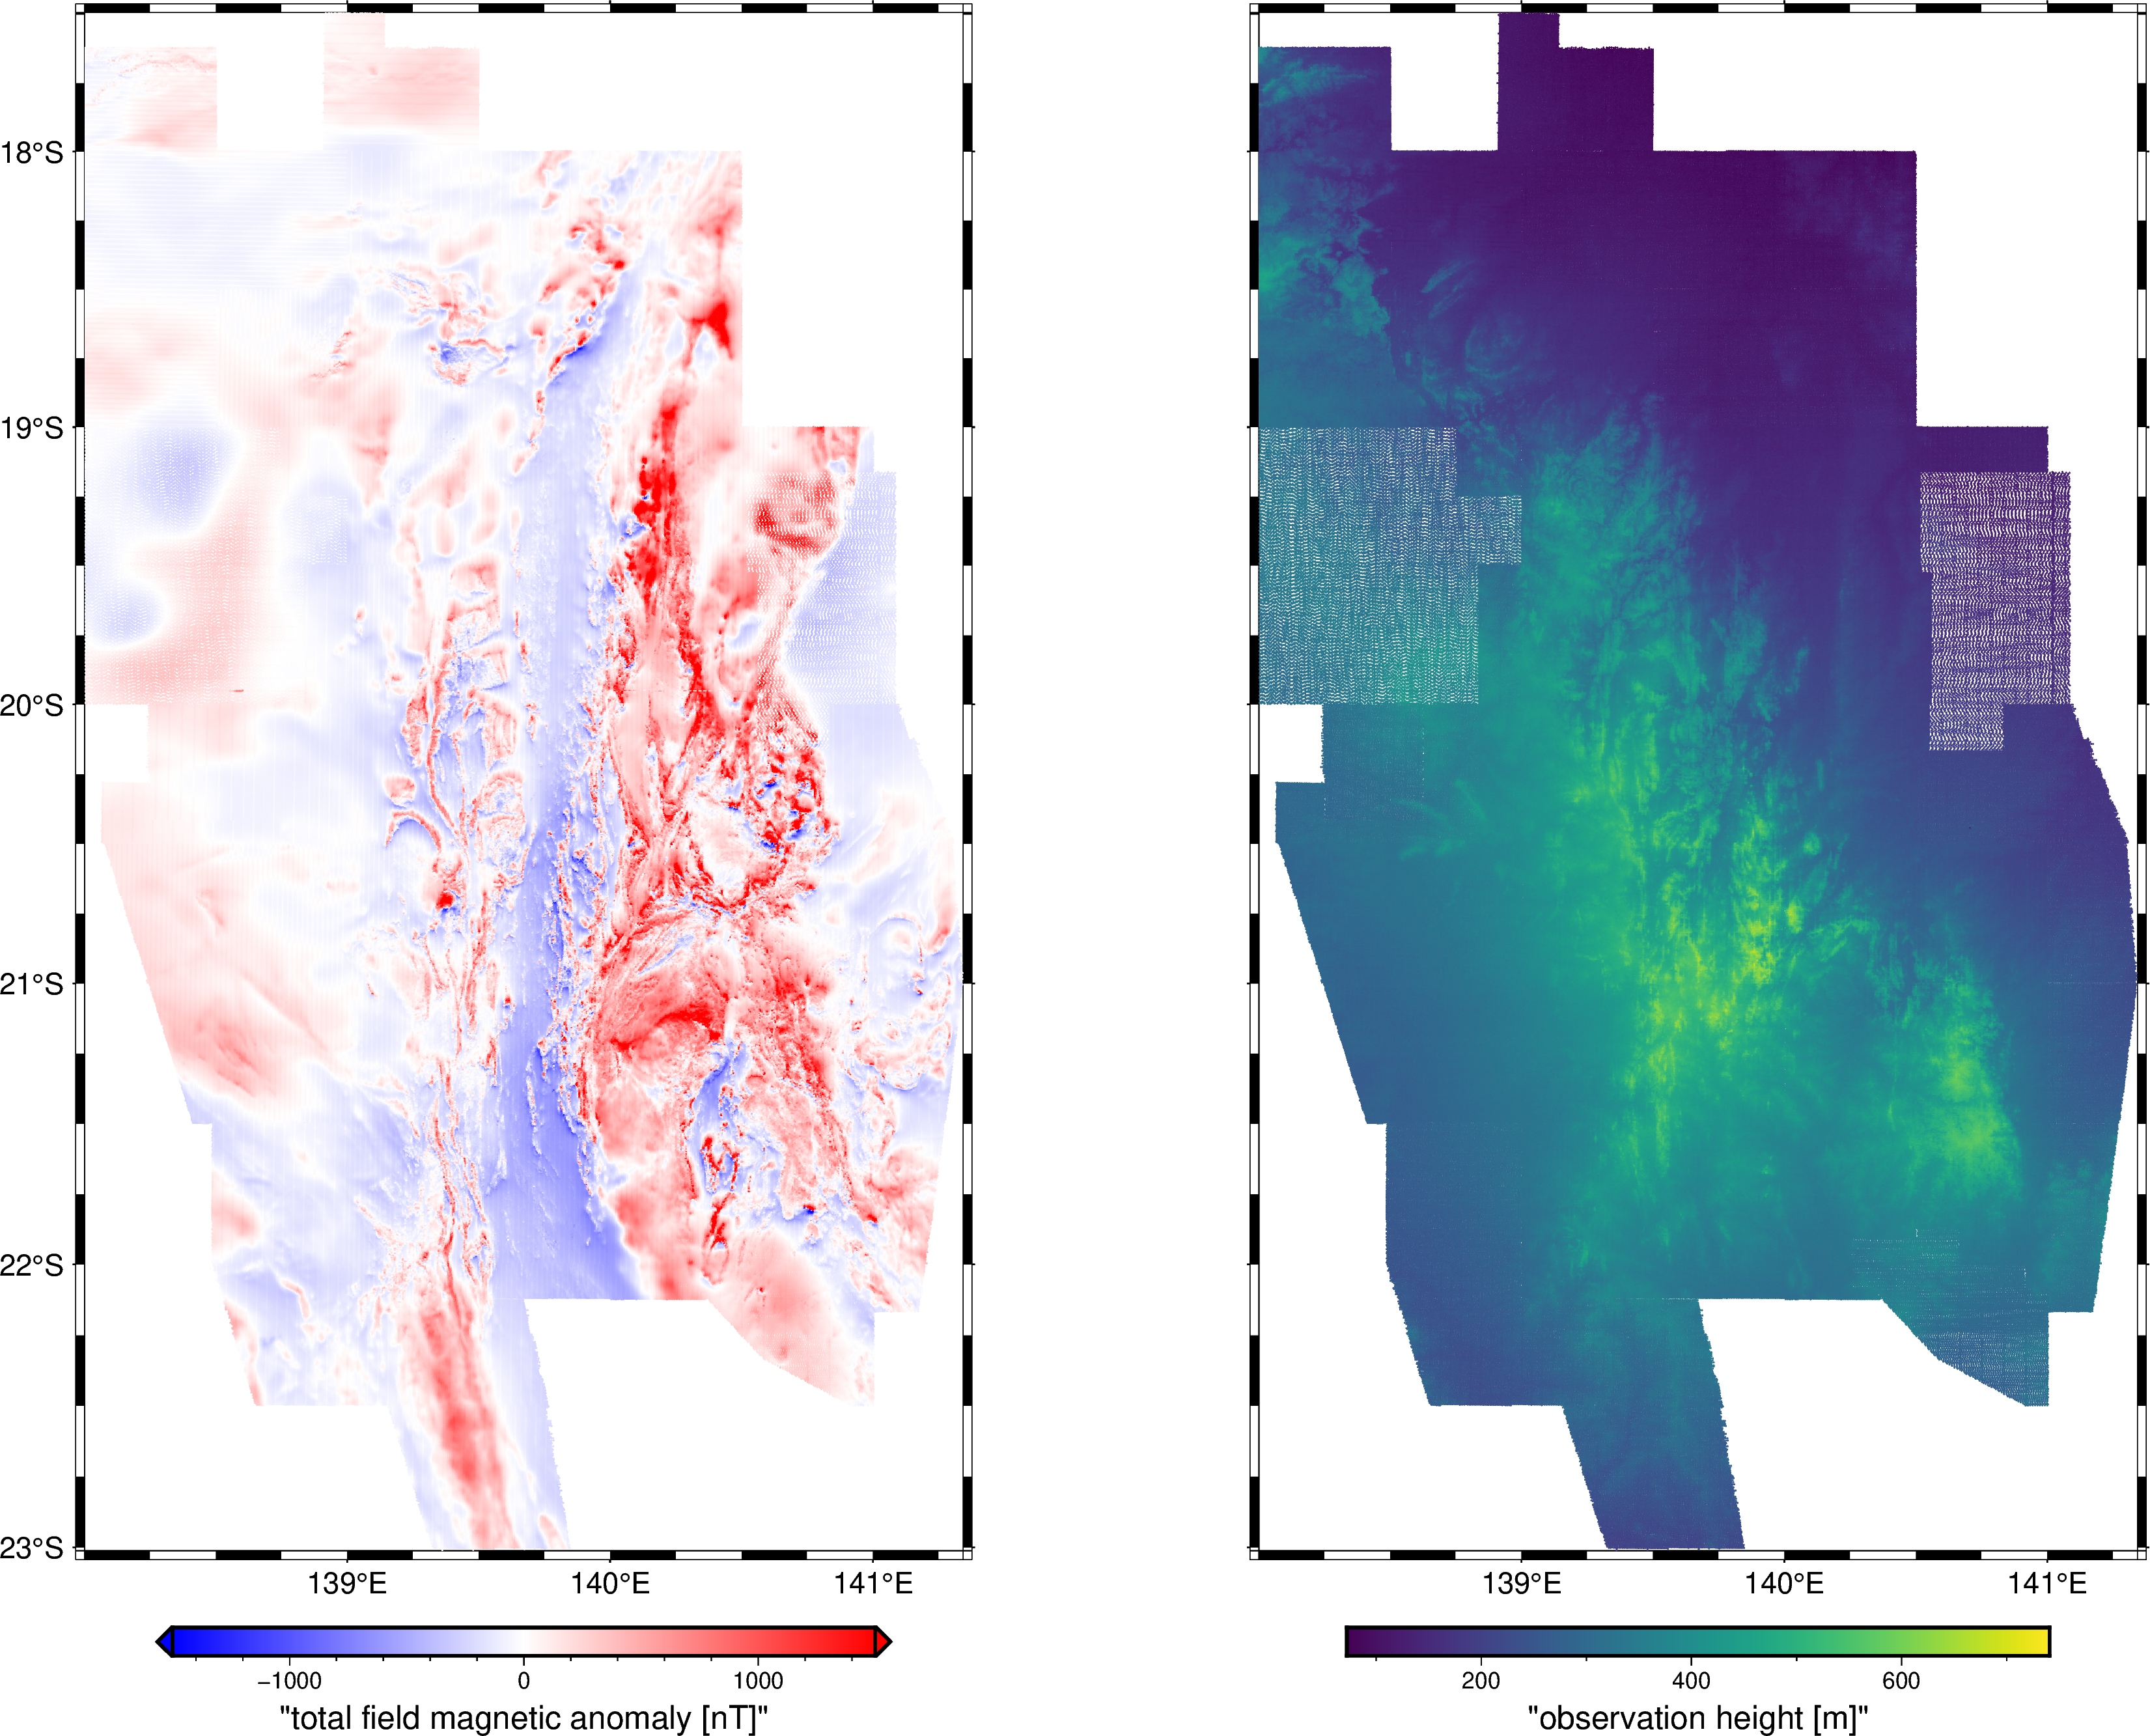

In [ ]:
data = data_df[::100]

fig = pygmt.Figure()
with fig.subplot(
    nrows=1,
    ncols=2,
    figsize=("30c", "20c"),
    sharey="l",  # shared y-axis on the left side
    frame="WSrt",
):
    with fig.set_panel(0):
        fig.basemap(projection="M?", region=region, frame="af")
        scale = 1500
        pygmt.makecpt(cmap="polar+h", series=[-scale, scale], background=True)
        fig.plot(
            x=data.longitude,
            y=data.latitude,
            fill=data.total_field_anomaly_awags_levelled,
            style="c0.02c",
            cmap=True,
        )
        fig.colorbar(
            frame="af+ltotal field magnetic anomaly [nT]",
            position="JBC+h+o0/1c+e",
        )
    with fig.set_panel(1):
        fig.basemap(projection="M?", region=region, frame="af")
        pygmt.makecpt(
            cmap="viridis",
            series=[data.height_orthometric_m.min(), data.height_orthometric_m.max()],
        )
        fig.plot(
            x=data.longitude,
            y=data.latitude,
            fill=data.height_orthometric_m,
            style="c0.02c",
            cmap=True,
        )
        fig.colorbar(
            frame="af+lobservation height [m]",
            position="JBC+h+o0/1c",
        )
fig.show(width=800)

## Subset a region

In [15]:
# West, East, South, North
region = (140 + 30 / 60, 140 + 50 / 60, -22 - 10 / 60, -21 - 45 / 60)
selection = vd.inside((data_df.longitude_gda, data_df.latitude_gda), region)
data = data_df[selection].reset_index(drop=True).copy()
data

,longitude_gda,latitude_gda,terrain_clearance_m,total_field_anomaly_awags_levelled,total_field_anomaly_microlevelled,total_field_anomaly_levelled,flight_line
0,140.664104,-21.868339,80.699997,-124.284653,4792.552734,-123.529999,5576
1,140.664018,-21.868339,80.599998,-124.181824,4792.656250,-123.410004,5576
2,140.663932,-21.868338,80.599998,-124.069214,4792.769531,-123.279999,5576
3,140.663847,-21.868338,80.500000,-123.946846,4792.892578,-123.139999,5576
4,140.663762,-21.868338,80.400002,-123.834244,4793.005859,-123.010002,5576
...,...,...,...,...,...,...,...
990982,140.507566,-21.870240,79.269997,-66.726227,4851.339844,-99.660004,10166
990983,140.507566,-21.870299,79.400002,-66.385582,4851.680176,-99.320000,10166
990984,140.507567,-21.870357,79.580002,-66.055672,4852.009766,-98.989998,10166
990985,140.507568,-21.870412,79.790001,-65.685265,4852.379883,-98.620003,10166


In [ ]:
airbornegeo.plotly_points(
    data_df[::10],  # plot every 10th point
    color_col="line",
    hover_cols=["line_name"],
    robust=False,
    size=3,
)

In [ ]:
# drop a few lines to clean up the survey
data_df = data_df[
    ~data_df.line_name.isin(
        [
            "BYRD1_69.0",
            "BYRD2_69.0",
            "BYRD3_69.0",
            "TAM1_4.0",
            "CTAM1_5.0",
            "SP10030_65.0",
            "F10291_37.0",
            "V10250_41.0",
        ]
    )
]

In [ ]:
# convert supplied line names and flights into integers
data_df["line"] = airbornegeo.unique_line_id(data_df, line_col_name="line_name")

# drop unneeded columns
data_df = data_df.drop(columns=["Flight_ID", "Line_no"])

# drop rows with all NaNs
data_df = data_df.dropna(how="all")

data_df

In [ ]:
airbornegeo.plotly_points(
    data_df[::10],
    color_col="line",
    hover_cols=["line_name"],
    robust=False,
    size=3,
)

In [ ]:
# calculate the unixtime from the date and time columns
data_df["Date"] = pd.to_datetime(data_df["Date"])
data_df["Time"] = pd.to_timedelta(data_df["Time"])
data_df["unixtime"] = data_df["Date"] + data_df["Time"]
data_df = data_df.dropna(subset=["unixtime"])
data_df["unixtime"] = data_df["unixtime"].apply(lambda x: x.timestamp())
data_df = data_df.sort_values(["line", "unixtime"]).reset_index(drop=True)
data_df.head()

In [ ]:
airbornegeo.plotly_points(
    data_df[::10],
    color_col="unixtime",
    hover_cols=["line"],
    robust=False,
    size=3,
)

In [ ]:
data_df.to_csv("data/AGAP_magnetic_survey.csv", index=False)